<a href="https://colab.research.google.com/github/jschmidt241/GPEP_LTAM/blob/main/tools/data_prep.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [12]:
!pip install netCDF4
!pip install rasterio

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Get station data
Download GHCN station data from the Climate Data Online API for the states (and province) that contain(s) any of the Great Lakes Region

In [23]:
import pandas as pd
import requests
import gzip
import io
import os
from google.colab import userdata

In [9]:
# Configuration
START_YEAR = 1970
END_YEAR = 2025
CORE_ELEMENTS = ["PRCP", "TMAX", "TMIN"]

# NOAA GHCN FTP/HTTP URLs
STATIONS_URL = "https://www.ncei.noaa.gov/pub/data/ghcn/daily/ghcnd-stations.txt"
DATA_URL_TEMPLATE = "https://www.ncei.noaa.gov/pub/data/ghcn/daily/by_year/{year}.csv.gz"

In [4]:
# ghcnd-stations.txt has fixed-width formatting
# Columns: ID (1-11), LAT (13-20), LON (22-30), ELEV (32-37), STATE (39-40), NAME (42-71), GSN (72-75), HCN/CRN (76-79), WBAN (80-86)
stations_df = pd.read_fwf(
    STATIONS_URL,
    colspecs=[(0, 11), (12, 20), (21, 30), (31, 37), (38, 40), (41, 71),(72,75),(76,79),(80,86)],
    names=["station_id", "latitude", "longitude", "elevation", "state", "station_name","gsn","hcn_crn","wban"],
    header=None
)

In [5]:
# Filter stations
stations_df["country"] = stations_df["station_id"].str[0:2]
filtered_stations = stations_df.loc[((stations_df["country"] == "US") | (stations_df["country"] == "CA")) &
                                     ((stations_df["state"]   == "MI") |
                                      (stations_df["state"]   == "WI") |
                                      (stations_df["state"]   == "MN") |
                                      (stations_df["state"]   == "IL") |
                                      (stations_df["state"]   == "ON") |
                                      (stations_df["state"]   == "IN") |
                                      (stations_df["state"]   == "OH") |
                                      (stations_df["state"]   == "NY") |
                                      (stations_df["state"]   == "PA"))]

In [6]:
filtered_stations.to_csv(f'{userdata.get('drive_path')}/stations/all_stations_6_17.csv',index=False)

In [6]:
station_ids = filtered_stations["station_id"].tolist()

In [10]:
all_years_data = []

for year in range(START_YEAR, END_YEAR + 1):
    print(f"Processing year: {year}")
    url = DATA_URL_TEMPLATE.format(year=year)

    # Download the gzipped CSV file into memory
    response = requests.get(url)
    if response.status_code != 200:
        print(f"Failed to download data for year {year}")
        continue

    with gzip.open(io.BytesIO(response.content), 'rt') as f:
        # NOAA GHCN daily CSV format:
        # Station_ID, Date (YYYYMMDD), Element, Value, M-Flag, Q-Flag, S-Flag, Source_Time
        df = pd.read_csv(
            f,
            header=None,
            names=["station_id", "date", "element", "value", "m_flag", "q_flag", "s_flag", "obs_time"],
            parse_dates=["date"],
            dtype={"station_id": str, "element": str, "value": float}
        )

    # Filter for specified stations
    df = df[df["station_id"].isin(station_ids) & df["element"].isin(CORE_ELEMENTS)]
    df.to_csv(f'{userdata.get('drive_path')}/stations/raw_data/{year}.csv')
    del response

Processing year: 1970...
Processing year: 1971...
Processing year: 1972...
Processing year: 1973...
Processing year: 1974...
Processing year: 1975...
Processing year: 1976...
Processing year: 1977...
Processing year: 1978...
Processing year: 1979...


### Get Raster Elevation Data
download copernicus 30m data in chunks from opentopo

In [4]:
gl_bbox = [-94.0,41.0,-74.0,51.0]
gl_bboxes = [['40.0', '51.0', '-94.0','-90.0'],
             ['40.0', '51.0', '-90.0','-86.0'],
             ['40.0', '51.0', '-86.0','-82.0'],
             ['40.0', '51.0', '-82.0','-78.0'],
             ['40.0', '51.0', '-78.0','-74.0']]

In [8]:
opentopo_dem_types = {
 'SRTM GL3 90m':'SRTMGL3',
 'SRTM GL1 30m':'SRTMGL1',
 'SRTM GL1 Ellipsoidal 30m':'SRTMGL1_E',
 'ALOS World 3D 30m':'AW3D30',
 'ALOS World 3D Ellipsoidal, 30m':'AW3D30_E',
 'Global Bathymetry SRTM15+ V2.1 500m':'SRTM15Plus',
 'NASADEM Global DEM':'NASADEM',
 'Copernicus Global DSM 30m':'COP30',
 'Copernicus Global DSM 90m':'COP90',
 'DTM 30m':'EU_DTM',
 'DTM 1000m':'GEDI_L3',
 'Global Bathymetry 500m':'GEBCOIceTopo',
 'Global Bathymetry 500m':'GEBCOSubIceTopo',
 'DSM 30m':'CA_MRDEM_DSM',
 'DTM 30m':'CA_MRDEM_DTM'
}

In [9]:
output_dir = f'{userdata.get('drive_path')}/rasters/opentopo/'
os.makedirs(output_dir, exist_ok=True)

dem_code = opentopo_dem_types.get('Copernicus Global DSM 30m')

for i, (b1, b2, b3, b4) in enumerate(gl_bboxes):
    url = f"https://portal.opentopography.org/API/globaldem?demtype={dem_code}&south={b1}&north={b2}&west={b3}&east={b4}&outputFormat=GTiff&API_Key={userdata.get('opentopo')}"
    print(f"Downloading raster {i+1} for bbox: south={b1}, north={b2}, west={b3}, east={b4}")

    response = requests.get(url, stream=True)

    if response.status_code == 200:
        filename = f"{dem_code}_{b1}_{b2}_{b3}_{b4}".replace('-','').replace('.','') + ".tif"
        filepath = os.path.join(output_dir, filename)
        with open(filepath, 'wb') as f:
            for chunk in response.iter_content(chunk_size=8192):
                f.write(chunk)
        print(f"Saved to {filepath}")
    else:
        print(f"Failed to download. Status code: {response.status_code}")
        print(response.text)


Saved to /content/drive/MyDrive/capstone_data/rasters/opentopo/COP30_400_510_940_900.tif
Saved to /content/drive/MyDrive/capstone_data/rasters/opentopo/COP30_400_510_900_860.tif
Saved to /content/drive/MyDrive/capstone_data/rasters/opentopo/COP30_400_510_860_820.tif
Saved to /content/drive/MyDrive/capstone_data/rasters/opentopo/COP30_400_510_820_780.tif
Saved to /content/drive/MyDrive/capstone_data/rasters/opentopo/COP30_400_510_780_740.tif


#Creating domain grid
With a customizable bbox and resolution, can include elevation data from a raster as well

In [28]:
import rasterio
import rasterio.merge as merge
import netCDF4 as nc
import numpy as np
from rasterio.plot import show
from rasterio.warp import reproject, Resampling
from rasterio.transform import from_bounds
import xarray as xr
import matplotlib.pyplot as plt
import glob

In [15]:
elevation_raster_paths = [f'{userdata.get('drive_path')}/rasters/opentopo/COP30_400_510_780_740.tif',
                          f'{userdata.get('drive_path')}/rasters/opentopo/COP30_400_510_820_780.tif',
                          f'{userdata.get('drive_path')}/rasters/opentopo/COP30_400_510_860_820.tif',
                          f'{userdata.get('drive_path')}/rasters/opentopo/COP30_400_510_900_860.tif',
                          f'{userdata.get('drive_path')}/rasters/opentopo/COP30_400_510_940_900.tif']
elevation_rasters = [rasterio.open(path) for path in elevation_raster_paths]
merged_elevation, output_transform = merge.merge(elevation_rasters)

In [16]:
out_meta = elevation_rasters[0].meta.copy()
out_meta.update({
    "driver": "GTiff",
    "height": merged_elevation.shape[1],
    "width": merged_elevation.shape[2],
    "transform": output_transform
})

In [2]:
full_elevation_raster_path = f"{userdata.get('drive_path')}/rasters/opentopo/COP30_GL_MOSAIC.tif"

In [17]:
with rasterio.open(full_elevation_raster_path, "w", **out_meta) as dest:
    dest.write(merged_elevation)
# close all open raster files
for rast in elevation_rasters:
    rast.close()

In [5]:
# define the grid parameters aligned to 0.02 increments
dx_val = 0.02
dy_val = 0.02
lat_min, lat_max = gl_bbox[1], gl_bbox[3]
lon_min, lon_max = gl_bbox[0], gl_bbox[2]

# generate 1D coordinate arrays (South to North, West to East)
# Treat min/max as outermost extents; offset by half cell size to get cell centers
lats_1d = np.arange(lat_min + dy_val / 2, lat_max, dy_val)
lons_1d = np.arange(lon_min + dx_val / 2, lon_max, dx_val)

ny = len(lats_1d)
nx = len(lons_1d)

# create 2D meshgrids for the spatially varying variables
lon_2d, lat_2d = np.meshgrid(lons_1d, lats_1d)

print("aggregating elevation data using mean")
west = lon_min
south = lat_min
east = lon_max
north = lat_max

# standard raster transform (north-up)
transform = from_bounds(west, south, east, north, nx, ny)
elev_grid = np.zeros((ny, nx), dtype=np.float32)

with rasterio.open(full_elevation_raster_path) as src:
    reproject(
        source=rasterio.band(src, 1),
        destination=elev_grid,
        src_transform=src.transform,
        src_crs=src.crs,
        dst_transform=transform,
        dst_crs=src.crs,
        resampling=Resampling.average
    )

# lats_1d goes from S to N, so flip elev_grid to match orientation
elev_grid = np.flipud(elev_grid)

print("Calculating slopes")
# Calculate distances using WGS84 ellipsoid parameters for better accuracy
a = 6378137.0  # Equatorial radius in meters
e2 = 0.00669437999014  # Eccentricity squared

lat_rad = np.radians(lat_2d)

# M is the radius of curvature in the meridian (North-South)
M = a * (1 - e2) / np.power((1 - e2 * np.sin(lat_rad)**2), 1.5)
# N is the radius of curvature in the prime vertical (West-East)
N = a / np.sqrt(1 - e2 * np.sin(lat_rad)**2)

# calculate exact pixel dimensions in meters
dy_meters = dy_val * (np.pi / 180.0) * M
dx_meters = dx_val * (np.pi / 180.0) * N * np.cos(lat_rad)

# gradient outputs differences between adjacent grid cells
grad_y_raw, grad_x_raw = np.gradient(elev_grid)

# calculate dimensionless slopes (dz / distance)
slope_n_s = grad_y_raw / dy_meters
slope_w_e = grad_x_raw / dx_meters

# initialize NetCDF file
filename = f"{userdata.get('drive_path')}/gpep_ltam_v1_0/michdemo_6_19_domain_grid.nc"
print(f"Writing to {filename}")
with nc.Dataset(filename, "w", format="NETCDF4") as rootgrp:

    # create dimensions
    rootgrp.createDimension("param", 1)
    rootgrp.createDimension("y", ny)
    rootgrp.createDimension("x", nx)

    # create variables and attributes
    dx = rootgrp.createVariable("dx", "f8", ("param",))
    dx.long_name = "Grid spacing in x-direction"
    dx.units = "degrees"
    dx[0] = dx_val

    dy = rootgrp.createVariable("dy", "f8", ("param",))
    dy.long_name = "Grid spacing in y-direction"
    dy.units = "degrees"
    dy[0] = dy_val

    startx = rootgrp.createVariable("startx", "f8", ("param",))
    startx.long_name = "Lower left longitude center"
    startx[0] = lons_1d[0]

    starty = rootgrp.createVariable("starty", "f8", ("param",))
    starty.long_name = "Lower left latitude center"
    starty.units = "degrees"
    starty[0] = lats_1d[0]

    latitude = rootgrp.createVariable("latitude", "f8", ("y", "x"))
    latitude.long_name = "Latitude"
    latitude.units = "degrees_north"
    latitude[:, :] = lat_2d

    longitude = rootgrp.createVariable("longitude", "f8", ("y", "x"))
    longitude.long_name = "Longitude"
    longitude.units = "degrees_east"
    longitude[:, :] = lon_2d

    elev = rootgrp.createVariable("elev", "f8", ("y", "x"), fill_value=-999.0)
    elev.setncattr("name", "Elevation")
    elev.long_name = "Elevation of grid"
    elev.units = "m"
    elev[:, :] = elev_grid

    gradient_n_s = rootgrp.createVariable("gradient_n_s", "f8", ("y", "x"), fill_value=-999.0)
    gradient_n_s.setncattr("name", "N_S_Slope")
    gradient_n_s.long_name = "Smoothed Topographic Gradient (Slope) from North to South"
    gradient_n_s.units = "-"
    gradient_n_s[:, :] = slope_n_s

    gradient_w_e = rootgrp.createVariable("gradient_w_e", "f8", ("y", "x"), fill_value=-999.0)
    gradient_w_e.setncattr("name", "W_E_Slope")
    gradient_w_e.long_name = "Smoothed Topographic Gradient (Slope) from West to East"
    gradient_w_e.units = "-"
    gradient_w_e[:, :] = slope_w_e

    mask = rootgrp.createVariable("mask", "i4", ("y", "x"))
    mask.long_name = "Basin mask for running ensemble"
    mask.units = "-"
    mask[:, :] = np.ones((ny, nx), dtype=np.int32)

print(f"Successfully generated {filename} with aggregated elevation and slopes (y={ny}, x={nx})")

Aggregating elevation data using mean average...
Calculating slopes...
Writing to michdemo_6_8_domain_grid.nc...
Successfully generated michdemo_6_8_domain_grid.nc with aggregated elevation and slopes (y=500, x=1000)


In [9]:
filename = f"{userdata.get('drive_path')}/gpep_ltam_v1_0/michdemo_6_19_domain_grid.nc"
ds = xr.open_dataset(filename)
print(ds)

<xarray.Dataset> Size: 22MB
Dimensions:       (param: 1, y: 500, x: 1000)
Dimensions without coordinates: param, y, x
Data variables:
    dx            (param) float64 8B ...
    dy            (param) float64 8B ...
    startx        (param) float64 8B ...
    starty        (param) float64 8B ...
    latitude      (y, x) float64 4MB ...
    longitude     (y, x) float64 4MB ...
    elev          (y, x) float64 4MB ...
    gradient_n_s  (y, x) float64 4MB ...
    gradient_w_e  (y, x) float64 4MB ...
    mask          (y, x) int32 2MB ...


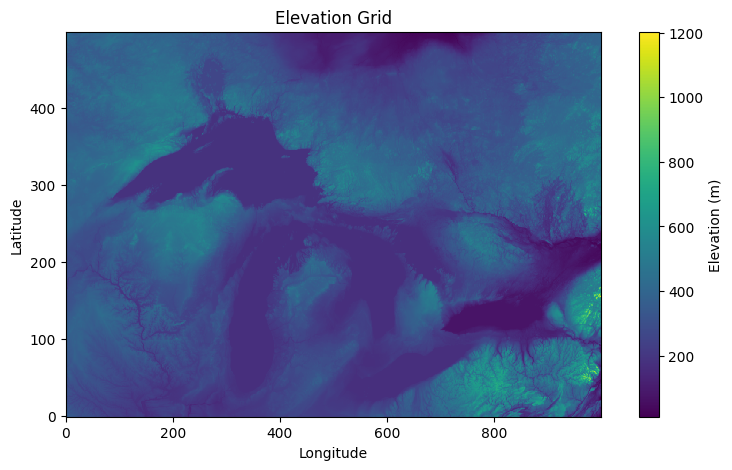

In [18]:
ds_elev = ds['elev']

fig, ax = plt.subplots(figsize=(10, 5))
ds_elev.plot(ax=ax, cbar_kwargs={'label': 'Elevation (m)'})

mid_lat = 46.0
ax.set_aspect(1 / np.cos(np.radians(mid_lat)))

ax.set_title('Elevation Grid')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')

plt.show()

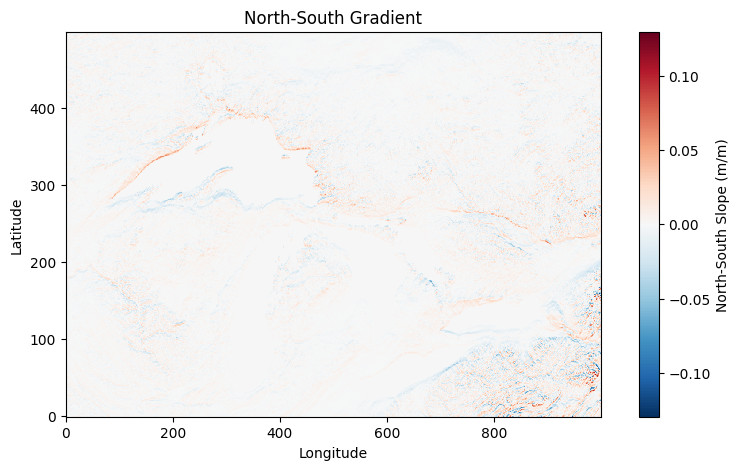

In [19]:
ds_grad_ns = ds['gradient_n_s']

fig, ax = plt.subplots(figsize=(10, 5))
ds_grad_ns.plot(ax=ax, cbar_kwargs={'label': 'North-South Slope (m/m)'})

mid_lat = 46.0
ax.set_aspect(1 / np.cos(np.radians(mid_lat)))

ax.set_title('North-South Gradient')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')

plt.show()

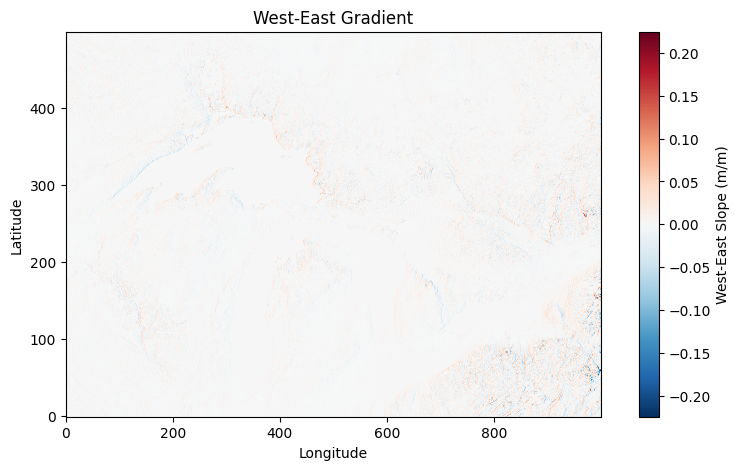

In [20]:
ds_grad_we = ds['gradient_w_e']

fig, ax = plt.subplots(figsize=(10, 5))
ds_grad_we.plot(ax=ax, cbar_kwargs={'label': 'West-East Slope (m/m)'})

mid_lat = 46.0
ax.set_aspect(1 / np.cos(np.radians(mid_lat)))

ax.set_title('West-East Gradient')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')

plt.show()

# Formatting station data

This code turns a series of CSVs containing station temperature and precipitation readings into a netcdf file where the dimensions are time and the station_id

In [21]:
all_station_list = f'{userdata.get('drive_path')}/stations/all_stations_6_17.csv'
input_directory =  f'{userdata.get('drive_path')}/stations/raw_data/'
output_directory = f'{userdata.get('drive_path')}/gpep_ltam_v1_0/inputs/stndata/'

In [26]:
all_station_df = pd.read_csv(all_station_list)
all_station_df

,station_id,latitude,longitude,elevation,state,station_name,gsn,hcn_crn,wban,country
0,CA006010735,53.8167,-89.9000,223.0,ON,BIG TROUT LAKE,NaN,NaN,71675.0,CA
1,CA006010738,53.8333,-89.8667,224.0,ON,BIG TROUT LAKE,NaN,NaN,NaN,CA
2,CA006010739,53.8167,-89.9000,222.0,ON,BIG TROUT LAKE READAC,GSN,NaN,71844.0,CA
3,CA006010740,53.8167,-89.9000,223.0,ON,BIG TROUT LAKE,NaN,NaN,71208.0,CA
4,CA006011305,51.5000,-90.1500,345.0,ON,CENTRAL PATRICIA,NaN,NaN,NaN,CA
...,...,...,...,...,...,...,...,...,...,...
17893,USW00094973,46.0303,-91.4425,368.8,WI,HAYWARD MUNI AP,NaN,NaN,NaN,US
17894,USW00094976,44.4500,-95.8167,360.9,MN,MARSHALL RYAN FLD,NaN,NaN,NaN,US
17895,USW00094985,44.6378,-90.1875,381.6,WI,MARSHFIELD MUNI AP,NaN,NaN,NaN,US
17896,USW00094992,47.7453,-90.3456,185.0,MN,GRAND MARAIS,NaN,NaN,NaN,US


In [41]:
# Extract slope data for stations
print("Sampling elevation/slope ds for each station")
startx = ds['startx'].values[0]
starty = ds['starty'].values[0]
dx = ds['dx'].values[0]
dy = ds['dy'].values[0]

# filter stations strictly within our domain bounds
valid_stns = all_station_df[
    (all_station_df['longitude'] >= ds['longitude'].min().values) &
    (all_station_df['longitude'] <= ds['longitude'].max().values) &
    (all_station_df['latitude'] >= ds['latitude'].min().values) &
    (all_station_df['latitude'] <= ds['latitude'].max().values)
].copy()

valid_stns['x_idx'] = np.round((valid_stns['longitude'] - startx) / dx).astype(int)
valid_stns['y_idx'] = np.round((valid_stns['latitude'] - starty) / dy).astype(int)

valid_stns['slp_n'] = ds['gradient_n_s'].values[valid_stns['y_idx'], valid_stns['x_idx']]
valid_stns['slp_e'] = ds['gradient_w_e'].values[valid_stns['y_idx'], valid_stns['x_idx']]
valid_stns = valid_stns.set_index('station_id')

Sampling elevation/slope ds for each station


In [42]:
# Load and pivot all ghcn-d csvs
print(f"loading time-series data from {input_directory}")
csv_files = glob.glob(os.path.join(input_directory, '*.csv'))
df_list = [pd.read_csv(f, usecols=['station_id', 'date', 'element', 'value'], parse_dates=['date']) for f in csv_files]
df_all = pd.concat(df_list, ignore_index=True)

# Filter only valid stations
df_all = df_all[df_all['station_id'].isin(valid_stns.index)]

print("pivoting into 2-dimensional matrices")
# Pivot elements out into their own columns (PRCP, TMAX, TMIN)
df_wide = df_all.pivot_table(index=['station_id', 'date'], columns='element', values='value').reset_index()

# Create 2D matrices: (station_id x date)
df_prcp = df_wide.pivot(index='station_id', columns='date', values='PRCP')
df_tmax = df_wide.pivot(index='station_id', columns='date', values='TMAX')
df_tmin = df_wide.pivot(index='station_id', columns='date', values='TMIN')

Loading time-series data from /content/drive/MyDrive/capstone_data/stations/raw_data/
Pivoting into 2-dimensional matrices


In [43]:
stn_ids = df_prcp.index.values.astype(str)
time_datetimes = df_prcp.columns.values

# Convert time to seconds since 1970-01-01 00:00:00
time_seconds = (time_datetimes - np.datetime64('1970-01-01T00:00:00')) / np.timedelta64(1, 's')
time_seconds = time_seconds.astype(np.int64)

num_stns = len(stn_ids)
num_times = len(time_seconds)
print(f"target dimensions: stn={num_stns}, time={num_times}")

prcp_mat = df_prcp.to_numpy().astype(np.float32)
tmax_mat = df_tmax.to_numpy().astype(np.float32)
tmin_mat = df_tmin.to_numpy().astype(np.float32)

# Generate 2D character array for IDs (stn x string11)
stnid_chars = np.zeros((num_stns, 11), dtype='S1')
for i, s_id in enumerate(stn_ids):
    padded_str = s_id.ljust(11)[:11]
    stnid_chars[i, :] = [c.encode('ascii') for c in padded_str]

Target dimensions: stn=10043, time=20454


In [45]:
# Save to strict NetCDF4 structure
output_nc_path = os.path.join(output_directory, 'glr_6_19_stations_input.nc')
os.makedirs(output_directory, exist_ok=True)

print("building netcdf")
with nc.Dataset(output_nc_path, "w", format="NETCDF4") as rootgrp:

    # Dimensions
    rootgrp.createDimension("stn", num_stns)
    rootgrp.createDimension("time", num_times)
    rootgrp.createDimension("string11", 11)

    # Variables
    stn = rootgrp.createVariable("stn", "i8", ("stn",))
    stn[:] = np.arange(num_stns, dtype=np.int64)

    time_var = rootgrp.createVariable("time", "i8", ("time",))
    time_var.units = "seconds since 1970-01-01 00:00:00"
    time_var[:] = time_seconds

    stnid = rootgrp.createVariable("stnid", "c", ("stn", "string11"))
    stnid[:, :] = stnid_chars

    lat = rootgrp.createVariable("lat", "f8", ("stn",))
    lat[:] = valid_stns.loc[stn_ids, 'latitude'].values.astype(np.float64)

    lon = rootgrp.createVariable("lon", "f8", ("stn",))
    lon[:] = valid_stns.loc[stn_ids, 'longitude'].values.astype(np.float64)

    elev = rootgrp.createVariable("elev", "f8", ("stn",))
    elev[:] = valid_stns.loc[stn_ids, 'elevation'].values.astype(np.float64)

    slp_n = rootgrp.createVariable("slp_n", "f8", ("stn",))
    slp_n[:] = valid_stns.loc[stn_ids, 'slp_n'].values.astype(np.float64)

    slp_e = rootgrp.createVariable("slp_e", "f8", ("stn",))
    slp_e[:] = valid_stns.loc[stn_ids, 'slp_e'].values.astype(np.float64)

    prcp = rootgrp.createVariable("prcp", "f4", ("stn", "time"))
    prcp[:, :] = prcp_mat

    tmin = rootgrp.createVariable("tmin", "f4", ("stn", "time"))
    tmin[:, :] = tmin_mat

    tmax = rootgrp.createVariable("tmax", "f4", ("stn", "time"))
    tmax[:, :] = tmax_mat

    tmean = rootgrp.createVariable("tmean", "f4", ("stn", "time"))
    tmean[:, :] = np.zeros((num_stns, num_times), dtype=np.float32)

    trange = rootgrp.createVariable("trange", "f4", ("stn", "time"))
    trange[:, :] = np.zeros((num_stns, num_times), dtype=np.float32)

print(f"File successfully saved to: {output_nc_path}")
del df_all
del df_wide
del df_prcp
del df_tmax
del df_tmin

Building NetCDF...
File successfully saved to: /content/drive/MyDrive/capstone_data/gpep_ltam_v1_0/inputs/stndata/glr_6_19_stations_input.nc


In [46]:
station_ds = xr.open_dataset(f'{userdata.get('drive_path')}/gpep_ltam_v1_0/inputs/stndata/glr_6_19_stations_input.nc')

In [47]:
station_ds

<xarray.Dataset> Size: 4GB
Dimensions:  (stn: 10043, time: 20454)
Coordinates:
  * stn      (stn) int64 80kB 0 1 2 3 4 5 ... 10038 10039 10040 10041 10042
  * time     (time) datetime64[ns] 164kB 1970-01-01 1970-01-02 ... 2025-12-31
Data variables:
    stnid    (stn) |S11 110kB ...
    lat      (stn) float64 80kB ...
    lon      (stn) float64 80kB ...
    elev     (stn) float64 80kB ...
    slp_n    (stn) float64 80kB ...
    slp_e    (stn) float64 80kB ...
    prcp     (stn, time) float32 822MB ...
    tmin     (stn, time) float32 822MB ...
    tmax     (stn, time) float32 822MB ...
    tmean    (stn, time) float32 822MB ...
    trange   (stn, time) float32 822MB ...